# Ontology Term Embeddings in OAK

This notebook introduces the `EmbeddingProviderInterface`, which gives direct access to
**vector embeddings of ontology terms** as numpy matrices and pandas DataFrames, along
with operations built on them (similarity, nearest neighbours, text search, and
best-match comparison of term sets).

Backends:

| Adapter | Models | Notes |
|---|---|---|
| `ols:<ontology>` | precomputed LLM embeddings hosted by [OLS](https://www.ebi.ac.uk/ols4) | several models, 512-d (PCA-reduced); cached locally |
| `llm:<adapter>` | any embedding model supported by the [llm](https://llm.datasette.io) library | embeds labels (or labels + definitions) on demand; cached locally |
| any adapter that can compute ancestors (e.g. `sqlite:obo:hp`) | `closure` | each term is a multi-hot vector of its reflexive ancestors |

The `closure` model is how "classic" ontology semantic similarity looks when written
as vectors. Jaccard similarity of closure vectors **is** the familiar ancestor-set Jaccard,
so classic and learned embeddings can be compared with exactly the same code.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="eutils")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import seaborn as sns

# reference palette (categorical slots in fixed order; sequential blue ramp)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})
SEQUENTIAL = sns.blend_palette(["#f0efec", "#86b6ef", "#2a78d6", "#0d366b"], as_cmap=True)

## Connecting to OLS

OLS serves embeddings for every class it indexes, for several models:

In [2]:
from oaklib import get_adapter

ols = get_adapter("ols:hp")
ols.embedding_models()

['harrier-oss-v1-27b_pca512',
 'llama-embed-nemotron-8b_pca512',
 'text-embedding-3-large_pca512',
 'text-embedding-3-small_pca512']

## Vectors as numpy and pandas

`entity_embeddings` returns the CURIEs that have vectors and a matrix with one row per
CURIE. Vectors are cached in a local sqlite database (under `~/.data/oaklib/embeddings`),
so OLS is only asked once per term and model.

In [3]:
hand_terms = [
    "HP:0001159",  # Syndactyly
    "HP:0006101",  # Finger syndactyly
    "HP:0001770",  # Toe syndactyly
    "HP:0001161",  # Hand polydactyly
    "HP:0001829",  # Foot polydactyly
    "HP:0001155",  # Abnormality of the hand
    "HP:0001760",  # Abnormal foot morphology
    "HP:0000568",  # Microphthalmia
    "HP:0000478",  # Abnormality of the eye
    "HP:0001250",  # Seizure
]
ids, matrix = ols.entity_embeddings(hand_terms)
matrix.shape

(10, 512)

In [4]:
ols.embeddings_dataframe(hand_terms, model="text-embedding-3-large_pca512").iloc[:, :6].round(3)

,0,1,2,3,4,5
id,,,,,,
HP:0001159,0.096,-0.007,-0.201,-0.119,-0.137,0.003
HP:0006101,0.064,-0.042,-0.216,-0.085,-0.159,0.000
HP:0001770,0.091,0.001,-0.189,-0.122,-0.142,-0.009
HP:0001161,0.068,-0.057,-0.183,-0.096,-0.152,-0.024
HP:0001829,0.084,-0.004,-0.178,-0.112,-0.172,-0.007
HP:0001155,0.108,-0.077,-0.241,-0.038,-0.166,-0.016
HP:0001760,0.109,-0.001,-0.228,-0.073,-0.172,-0.020
HP:0000568,0.087,-0.016,-0.254,-0.052,-0.169,0.053
HP:0000478,0.105,-0.047,-0.241,-0.033,-0.142,0.003


## Pairwise similarity

Scores are cosine similarities computed locally from the vectors. OLS's own similarity
endpoints report `(1 + cosine) / 2`; OAK converts these back to cosine so that all
scores are on the same scale
([#915](https://github.com/INCATools/ontology-access-kit/issues/915)).

Different models disagree substantially, even on the same pair of terms:

In [5]:
import pandas as pd

pairs = [
    ("HP:0001159", "HP:0006101"),  # syndactyly vs finger syndactyly (subclass)
    ("HP:0006101", "HP:0001770"),  # finger vs toe syndactyly (siblings)
    ("HP:0001159", "HP:0001161"),  # syndactyly vs hand polydactyly
    ("HP:0001159", "HP:0001250"),  # syndactyly vs seizure (unrelated)
]
labels = dict(ols.labels({t for p in pairs for t in p}))
rows = []
for model in ols.embedding_models():
    for s, o in pairs:
        rows.append({"model": model, "pair": f"{labels[s]} / {labels[o]}",
                     "cosine": ols.embedding_similarity(s, o, model=model)})
pd.DataFrame(rows).pivot(index="pair", columns="model", values="cosine").round(3)

model,harrier-oss-v1-27b_pca512,llama-embed-nemotron-8b_pca512,text-embedding-3-large_pca512,text-embedding-3-small_pca512
pair,,,,
Finger syndactyly / Toe syndactyly,0.853,0.906,0.846,0.854
Syndactyly / Finger syndactyly,0.939,0.875,0.922,0.871
Syndactyly / Hand polydactyly,0.806,0.648,0.815,0.724
Syndactyly / Seizure,0.369,0.366,0.268,0.392


Note that absolute cosine values are not comparable across models: each model has its
own "background" similarity for unrelated terms. Rankings within a model are what matter.

## Nearest neighbours and text search

`nearest_entities` uses the OLS vector index; results can come from any ontology in OLS
(useful for finding mappings). Obsolete classes are filtered out.

In [6]:
model = "text-embedding-3-large_pca512"
pd.DataFrame(
    [(c, ols.label(c), round(score, 3)) for c, score in ols.nearest_entities("HP:0001159", limit=8, model=model)],
    columns=["id", "label", "cosine"],
)

,id,label,cosine
0,HP:0006101,Finger syndactyly,0.922
1,HP:0001770,Toe syndactyly,0.909
2,HP:0010554,Cutaneous finger syndactyly,0.868
3,HP:0010704,1-2 finger cutaneous syndactyly,0.859
4,HP:0010709,2-4 finger cutaneous syndactyly,0.857
5,HP:0001233,2-3 finger cutaneous syndactyly,0.850
6,HP:0010713,1-5 toe syndactyly,0.844
7,HP:0006097,3-4 finger osseus syndactyly,0.842


Free-text queries are embedded by OLS. Only some OLS models can embed text; by default
the first such model is used, and results are restricted to the adapter's ontology:

In [7]:
pd.DataFrame(
    [(c, ols.label(c), round(score, 3)) for c, score in ols.nearest_entities_to_text("webbed fingers", limit=5)],
    columns=["id", "label", "cosine"],
)

,id,label,cosine
0,HP:0001159,Syndactyly,0.821
1,HP:0010704,1-2 finger cutaneous syndactyly,0.813
2,HP:0006101,Finger syndactyly,0.711
3,HP:0010554,Cutaneous finger syndactyly,0.696
4,HP:0010709,2-4 finger cutaneous syndactyly,0.686


## Classic semantic similarity as vectors: the `closure` model

Any adapter that can compute ancestors provides the `closure` model. Each term is a
multi-hot vector over the union of the ancestors of the terms being encoded:

In [8]:
from oaklib.utilities.embeddings.closure_embeddings import closure_embeddings

hp = get_adapter("sqlite:obo:hp")
ids, vocab, m = closure_embeddings(hp, hand_terms[:3])
closure_df = pd.DataFrame(m.astype(int), index=[hp.label(i) for i in ids], columns=[hp.label(v) for v in vocab])
print(closure_df.shape)
# show the dimensions (ancestors) that are not shared by all three terms
closure_df.loc[:, closure_df.sum() < 3]

(3, 16)


,Abnormal foot morphology,Toe syndactyly,Abnormal toe morphology,Abnormality of the lower limb,Finger syndactyly
Syndactyly,0,0,0,0,0
Finger syndactyly,0,0,0,0,1
Toe syndactyly,1,1,1,1,0


Jaccard similarity over closure vectors is identical to the ancestor-set Jaccard computed
by the `SemanticSimilarityInterface`:

In [9]:
from oaklib.datamodels.vocabulary import IS_A

for s, o in pairs:
    vec = hp.embedding_similarity(s, o, model="closure", metric="jaccard")
    classic = hp.pairwise_similarity(s, o, predicates=[IS_A]).jaccard_similarity
    print(f"{labels[s]:>20} / {labels[o]:<20} vector={vec:.4f} classic={classic:.4f}")

          Syndactyly / Finger syndactyly    vector=0.9167 classic=0.9167


   Finger syndactyly / Toe syndactyly       vector=0.6875 classic=0.6875


          Syndactyly / Hand polydactyly     vector=0.4762 classic=0.4762


          Syndactyly / Seizure              vector=0.1429 classic=0.1429


## Comparing the similarity structure of models

Below are all-by-all similarity matrices for the same ten terms: ontology closure
(cosine) versus two OLS-hosted LLM embedding models. The closure model only sees the
ontology graph; the LLM models only see the text of the terms.

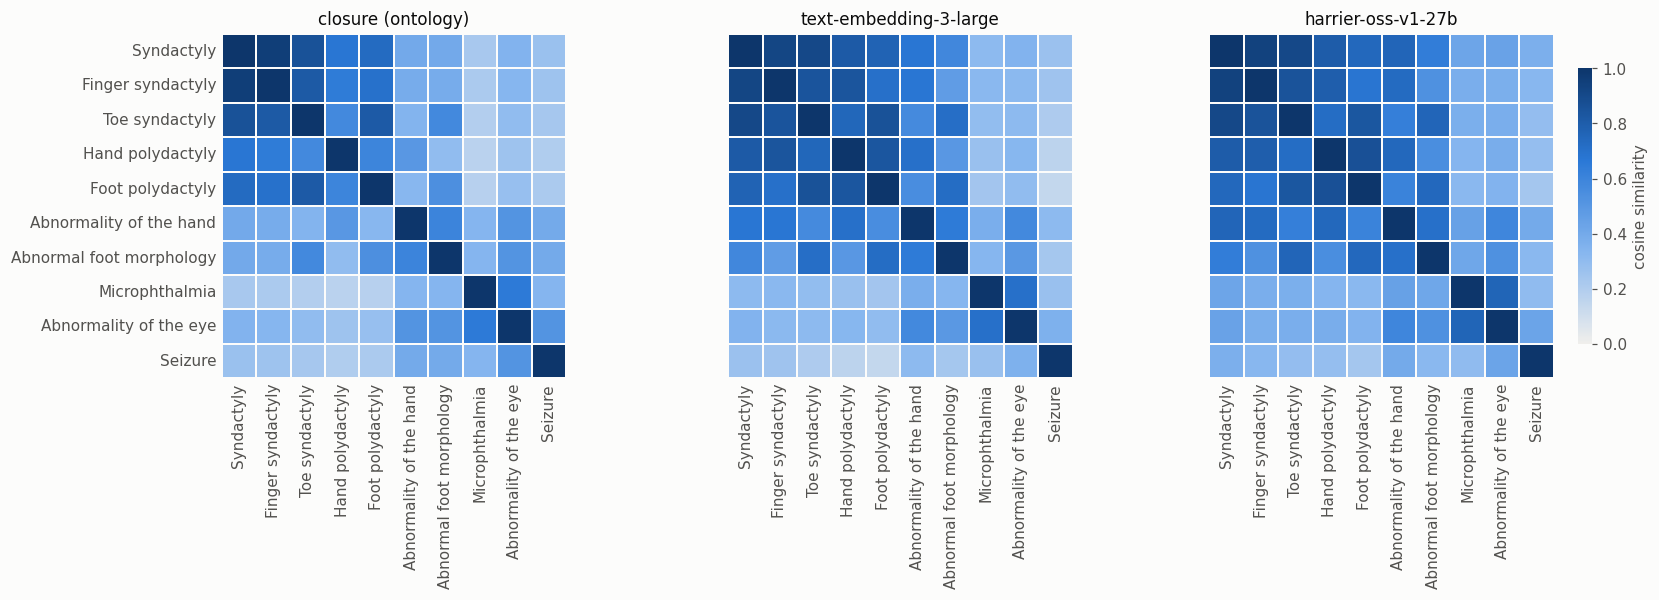

In [10]:
import numpy as np

short = {t: ols.label(t) for t in hand_terms}
panels = [
    ("closure (ontology)", hp, "closure"),
    ("text-embedding-3-large", ols, "text-embedding-3-large_pca512"),
    ("harrier-oss-v1-27b", ols, "harrier-oss-v1-27b_pca512"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True)
for ax, (title, adapter, model) in zip(axes, panels):
    m = adapter.embedding_similarity_matrix(hand_terms, model=model)
    m = m.rename(index=short, columns=short)
    sns.heatmap(m, ax=ax, cmap=SEQUENTIAL, vmin=0, vmax=1, square=True,
                cbar=ax is axes[-1], cbar_kws={"label": "cosine similarity", "shrink": 0.8},
                linewidths=1, linecolor=SURFACE)
    ax.set_title(title)
    ax.grid(False)
    ax.tick_params(length=0)
fig.tight_layout()

All three put the limb terms in one block, and the eye terms and seizure apart from it.
They differ in the details. The closure model scores the general terms ("Abnormality of
the hand", "Abnormal foot morphology") as only moderately similar to their own descendants,
because those descendants have many extra ancestors. The LLM models place them closer.
The two LLM models also have very different "background" similarity between unrelated terms
(compare the Seizure row). This is why absolute cosine thresholds do not transfer between
models; rankings within a model are more meaningful.

## Comparing sets of terms

`embedding_termset_similarity` compares two sets of terms (e.g. a patient profile and a
disease profile) by best-match average, returning the same `TermSetPairwiseSimilarity`
object as classic semantic similarity:

In [11]:
patient = ["HP:0006101", "HP:0000568"]           # finger syndactyly, microphthalmia
disease = ["HP:0001159", "HP:0000478", "HP:0001250"]  # syndactyly, eye abnormality, seizure
sim = ols.embedding_termset_similarity(patient, disease, model="text-embedding-3-large_pca512", labels=True)
print("best match average:", round(sim.average_score, 3))
for bm in sim.subject_best_matches.values():
    print(f"  {bm.match_source_label} -> {bm.match_target_label} ({bm.score:.3f})")

best match average: 0.705
  Finger syndactyly -> Syndactyly (0.922)
  Microphthalmia -> Abnormality of the eye (0.703)


## LLM embeddings computed on demand

The `llm:` adapter wraps another adapter and embeds term text with any model supported by
the `llm` library (OpenAI, sentence-transformers via plugins, ...). The text template is
configurable, so you can compare label-only with label + definition embeddings. This needs
an API key (or a local model plugin), so it is not run here:

```python
llm_adapter = get_adapter("llm:sqlite:obo:hp")
llm_adapter.embedding_model_id = "text-embedding-3-small"
llm_adapter.embedding_text_template = "{label}: {definition}"
ids, matrix = llm_adapter.entity_embeddings(hand_terms)
```

## Command line

The same operations are available from `runoak`:

```bash
runoak -i ols:hp embedding-models
runoak -i ols:hp embeddings .desc//p=i HP:0001155 -m text-embedding-3-large_pca512 -o hand.tsv
runoak -i ols:hp nearest-entities HP:0001159 -L 5
runoak -i ols:hp nearest-entities --text "webbed fingers"
runoak -i ols:hp embedding-similarity HP:0001159 HP:0006101 @ HP:0001770 HP:0001250
runoak -i sqlite:obo:hp embedding-similarity -m closure --metric jaccard HP:0001159 @ HP:0001770
```

## See also

- [Subsumption recapitulation](Subsumption-Recapitulation.ipynb): do LLM embeddings
  encode the ontology hierarchy?
- [Phenotype profile matching](Phenotype-Profile-Matching.ipynb): retrieving diseases from
  noisy phenotype profiles with classic and embedding-based similarity.